In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import TensorDataset, DataLoader

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Contemporary Issues in Analytics/Bank Chunners.csv")

df = df.iloc[:, :-2]
df.drop("CLIENTNUM", axis=1, inplace=True)

df.replace("Unknown", np.nan, inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

df['Attrition_Flag'] = df['Attrition_Flag'].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# SPLIT + SCALE (UNCHANGED)
X = df.drop("Attrition_Flag", axis=1).values
y = df["Attrition_Flag"].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Tensors
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_val   = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size)


/tmp/ipykernel_33019/1159932500.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [4]:
# DEEP CNN (8–12 LAYERS)
class DeepCNN(nn.Module):
    def __init__(self):
        super(DeepCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv1d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv1d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv1d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv1d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self._to_linear = None
        self._get_output()

        self.fc = nn.Sequential(
            nn.Linear(self._to_linear, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def _get_output(self):
        with torch.no_grad():
            x = torch.randn(1, 1, X_train.shape[2])
            x = self.conv(x)
            self._to_linear = x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# RESNET BLOCK (1D)
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.shortcut = nn.Conv1d(in_channels, out_channels, 1) \
            if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += identity
        return torch.relu(out)


# RESNET MODEL
class ResNet1D(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = ResidualBlock(1, 32)
        self.pool1 = nn.MaxPool1d(2)

        self.layer2 = ResidualBlock(32, 64)
        self.pool2 = nn.MaxPool1d(2)

        self.layer3 = ResidualBlock(64, 128)
        self.pool3 = nn.MaxPool1d(2)

        self.layer4 = ResidualBlock(128, 256)
        self.pool4 = nn.MaxPool1d(2)

        self._to_linear = None
        self._get_output()

        self.fc = nn.Sequential(
            nn.Linear(self._to_linear, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def _get_output(self):
        with torch.no_grad():
            x = torch.randn(1, 1, X_train.shape[2])
            x = self.pool1(self.layer1(x))
            x = self.pool2(self.layer2(x))
            x = self.pool3(self.layer3(x))
            x = self.pool4(self.layer4(x))
            self._to_linear = x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.pool1(self.layer1(x))
        x = self.pool2(self.layer2(x))
        x = self.pool3(self.layer3(x))
        x = self.pool4(self.layer4(x))

        x = x.view(x.size(0), -1)
        return self.fc(x)

In [7]:
# TRAIN FUNCTION
def train_model(model, train_loader, val_loader, epochs=15, lr=0.001, model_name="Model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    print(f"\n===== Training {model_name} =====")

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # VALIDATION
        model.eval()
        val_loss = 0
        preds, labels = [], []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                val_loss += criterion(outputs, y_batch).item()

                preds.extend(torch.argmax(outputs, 1).numpy())
                labels.extend(y_batch.numpy())

        val_acc = accuracy_score(labels, preds)

        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss / len(val_loader))
        history["val_acc"].append(val_acc)

        print(f"{model_name} | Epoch {epoch+1}: "
              f"Train Loss={history['train_loss'][-1]:.4f}, "
              f"Val Loss={history['val_loss'][-1]:.4f}, "
              f"Val Acc={val_acc:.4f}")

    return history

In [8]:
# TRAIN BOTH MODELS
cnn_model = DeepCNN()
resnet_model = ResNet1D()

cnn_history = train_model(
    cnn_model, train_loader, val_loader,
    model_name="Deep CNN"
)

resnet_history = train_model(
    resnet_model, train_loader, val_loader,
    model_name="ResNet"
)


===== Training Deep CNN =====
Deep CNN | Epoch 1: Train Loss=0.4120, Val Loss=0.3188, Val Acc=0.8716
Deep CNN | Epoch 2: Train Loss=0.2624, Val Loss=0.2225, Val Acc=0.9065
Deep CNN | Epoch 3: Train Loss=0.1821, Val Loss=0.1670, Val Acc=0.9210
Deep CNN | Epoch 4: Train Loss=0.1514, Val Loss=0.1579, Val Acc=0.9296
Deep CNN | Epoch 5: Train Loss=0.1368, Val Loss=0.1588, Val Acc=0.9375
Deep CNN | Epoch 6: Train Loss=0.1245, Val Loss=0.1987, Val Acc=0.9302
Deep CNN | Epoch 7: Train Loss=0.1170, Val Loss=0.1378, Val Acc=0.9460
Deep CNN | Epoch 8: Train Loss=0.1087, Val Loss=0.1854, Val Acc=0.9434
Deep CNN | Epoch 9: Train Loss=0.0983, Val Loss=0.1311, Val Acc=0.9526
Deep CNN | Epoch 10: Train Loss=0.0844, Val Loss=0.1525, Val Acc=0.9454
Deep CNN | Epoch 11: Train Loss=0.0771, Val Loss=0.1512, Val Acc=0.9526
Deep CNN | Epoch 12: Train Loss=0.0835, Val Loss=0.1511, Val Acc=0.9519
Deep CNN | Epoch 13: Train Loss=0.0614, Val Loss=0.1929, Val Acc=0.9460
Deep CNN | Epoch 14: Train Loss=0.0624, Va


Deep CNN Accuracy: 0.9349
Deep CNN ROC-AUC: 0.9758


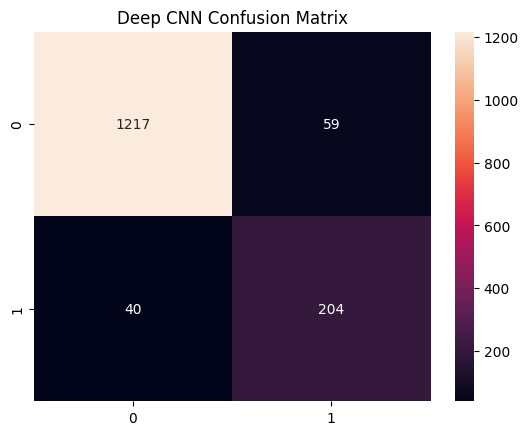


ResNet Accuracy: 0.9349
ResNet ROC-AUC: 0.9680


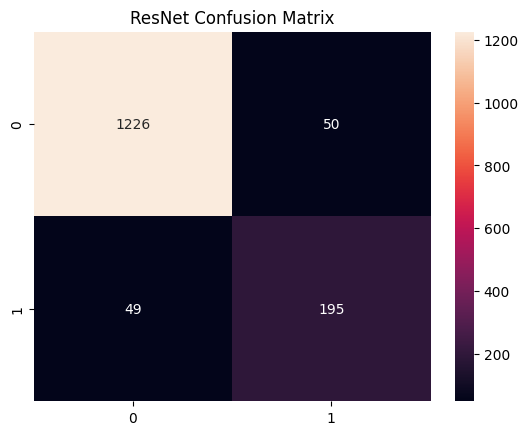

In [9]:
# EVALUATION FUNCTION
def evaluate(model, loader, name="Model"):
    model.eval()
    preds, labels, probs = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            prob = torch.softmax(outputs, dim=1)

            preds.extend(torch.argmax(outputs, 1).numpy())
            labels.extend(y_batch.numpy())
            probs.extend(prob[:,1].numpy())

    acc = accuracy_score(labels, preds)
    roc = roc_auc_score(labels, probs)
    cm = confusion_matrix(labels, preds)

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(f"{name} ROC-AUC: {roc:.4f}")

    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

# Evaluate
evaluate(cnn_model, test_loader, "Deep CNN")
evaluate(resnet_model, test_loader, "ResNet")

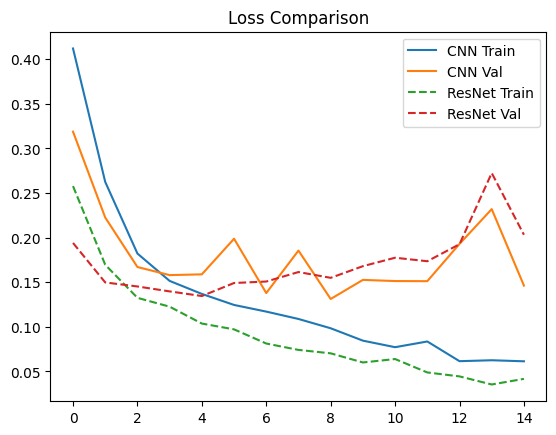

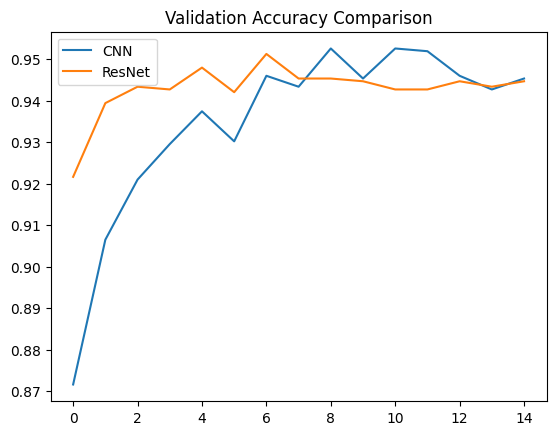

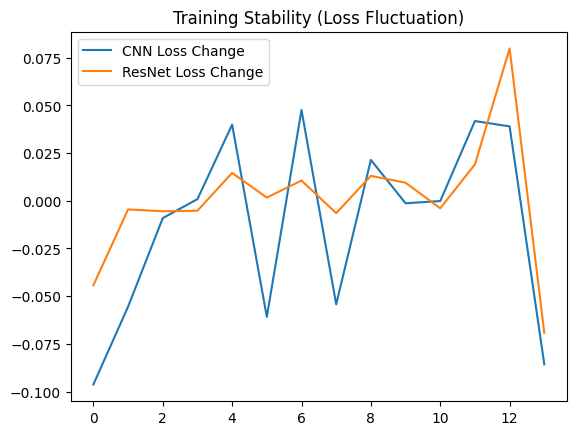

In [10]:
# COMPARATIVE VISUALIZATIONS
# LOSS CURVES
plt.plot(cnn_history["train_loss"], label="CNN Train")
plt.plot(cnn_history["val_loss"], label="CNN Val")
plt.plot(resnet_history["train_loss"], '--', label="ResNet Train")
plt.plot(resnet_history["val_loss"], '--', label="ResNet Val")
plt.legend()
plt.title("Loss Comparison")
plt.show()

# ACCURACY CURVES
plt.plot(cnn_history["val_acc"], label="CNN")
plt.plot(resnet_history["val_acc"], label="ResNet")
plt.legend()
plt.title("Validation Accuracy Comparison")
plt.show()

# TRAINING STABILITY (LOSS SMOOTHNESS)
plt.plot(np.diff(cnn_history["val_loss"]), label="CNN Loss Change")
plt.plot(np.diff(resnet_history["val_loss"]), label="ResNet Loss Change")
plt.legend()
plt.title("Training Stability (Loss Fluctuation)")
plt.show()

In [12]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

torch.save(cnn_model, "cnn_model.pth")
torch.save(resnet_model, "resnet_model.pth")

with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

In [13]:
from google.colab import files

files.download("cnn_model.pth")
files.download("resnet_model.pth")
files.download("scaler.pkl")
files.download("label_encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>